### Import analysis libraries

Load plotting, date/time, table, numerical, signal-processing, filesystem, audio, JSON, subprocess, and coordinate-transformation tools used throughout the notebook.


In [1]:
import matplotlib.pyplot as plt
import datetime as dt
import pandas as pd
import numpy as np
import scipy as sp

from pathlib import Path
import soundfile as sf
import json
import subprocess

from pyproj import Transformer


### Import interactive mapping

Load Folium to display microphone positions and estimated sound-source locations on geographic maps.


In [2]:
import folium

### Import the local audio-processing module

Load `UBNA_localize_process_GCC__20250505` as `localize`. Later cells use its `highpass_audio_signal` helper; the module must be available on the notebook’s Python import path.


In [3]:
import UBNA_localize_process_GCC__20250505 as localize

### Find recording and synchronization files

Search the `STF_*` folders inside `/Volumes/Elements/recover-20260604` for raw WAV recordings, Python-synchronized WAV recordings, and uppercase `.CSV` files. Display the three file lists to inspect what is available; this cell only discovers paths.


In [4]:
HARD_DRIVE_LOC = Path('/Volumes/Elements')
experiment_folder = HARD_DRIVE_LOC / 'recover-20260604'
all_wav_files = list(experiment_folder.glob('STF_*/2026*0.WAV'))
all_sync_wav_files = list(experiment_folder.glob('STF_*/2026*PYTHON_SYNC.WAV'))
all_csv_files = list(experiment_folder.glob('STF_*/2026*.CSV'))
all_wav_files, all_sync_wav_files, all_csv_files

([PosixPath('/Volumes/Elements/recover-20260604/STF_021/20260604_203000.WAV'),
  PosixPath('/Volumes/Elements/recover-20260604/STF_025/20260604_203000.WAV'),
  PosixPath('/Volumes/Elements/recover-20260604/STF_030/20260604_203000.WAV'),
  PosixPath('/Volumes/Elements/recover-20260604/STF_027/20260604_203000.WAV'),
  PosixPath('/Volumes/Elements/recover-20260604/STF_060/20260604_203000.WAV'),
  PosixPath('/Volumes/Elements/recover-20260604/STF_113/20260604_203000.WAV'),
  PosixPath('/Volumes/Elements/recover-20260604/STF_116/20260604_203000.WAV')],
 [PosixPath('/Volumes/Elements/recover-20260604/STF_021/20260604_203000_PYTHON_SYNC.WAV'),
  PosixPath('/Volumes/Elements/recover-20260604/STF_025/20260604_203000_PYTHON_SYNC.WAV'),
  PosixPath('/Volumes/Elements/recover-20260604/STF_030/20260604_203000_PYTHON_SYNC.WAV'),
  PosixPath('/Volumes/Elements/recover-20260604/STF_027/20260604_203000_PYTHON_SYNC.WAV'),
  PosixPath('/Volumes/Elements/recover-20260604/STF_060/20260604_203000_PYTHON_SYN

### Associate SD cards with AudioMoth devices

Define the lookup from each `STF_*` folder to its AudioMoth identifier and display it. Initialize the spectrogram frequency-display limit to `6/8`; a later cell changes this setting.


In [5]:
SD_CARD_TO_AUDIOMOTH_NUM = {'STF_026': '014', 'STF_028' : '045', 
                            'STF_057': '015', 'STF_109': '008', 
                            'STF_114': '040', 'STF_053': '032', 
                            'STF_021': '016', 'STF_116': '036', 
                            'STF_060': '004', 'STF_025': '042',  
                            'STF_027': '020',
                            'STF_113': '044', 'STF_030': '012'}
FREQ_UPPER_LIM = 6/8
SD_CARD_TO_AUDIOMOTH_NUM

{'STF_026': '014',
 'STF_028': '045',
 'STF_057': '015',
 'STF_109': '008',
 'STF_114': '040',
 'STF_053': '032',
 'STF_021': '016',
 'STF_116': '036',
 'STF_060': '004',
 'STF_025': '042',
 'STF_027': '020',
 'STF_113': '044',
 'STF_030': '012'}

### Associate devices with deployment positions

Map AudioMoth identifiers to their Patch A and Patch E post positions, including top/bottom placement. Combine both mappings for plot labels; the Patch E mapping also selects which recordings enter the audio analysis.


In [6]:
AUDIOMOTH_AT_PATCHA = {'014':'A1 (top)', '045':'A1 (bottom)',
                       '015':'A4 (top)', '008':'A4 (bottom)',
                       '040':'A7 (top)', '032':'A7 (bottom)'}
AUDIOMOTH_AT_PATCHE = {'016':'E2 (top)', '036':'E2 (bottom)',
                       '004':'E4 (top)', '042':'E4 (bottom)',
                       '020':'E8 (alone)',
                       '044':'E9 (top)', '012':'E9 (bottom)'}

AUDIOMOTH_AT_ALLPATCHES = AUDIOMOTH_AT_PATCHA | AUDIOMOTH_AT_PATCHE

### Collect post coordinates from photographs and measurements

Find HEIC photographs beneath `~/Downloads/audiomoth50_fencepost_pics` and use the external `exiftool` command to read numeric GPS metadata. Associate each geotagged photo with its parent-folder name. If `post_A7/Raw Data.csv` exists, retain the middle 20% of its rows and extract nonmissing latitude/longitude values. Combine photograph and measurement coordinates into `marker_locations`, with lime and magenta color labels respectively.


In [7]:
photo_dir = Path.home() / "Downloads/audiomoth50_fencepost_pics"
photo_paths = sorted(photo_dir.rglob("*.HEIC"))

photo_metadata = []
if len(photo_paths) > 0:
    photo_metadata = json.loads(subprocess.check_output(["exiftool", "-json", "-n", *[str(path) for path in photo_paths]], text=True))

photo_marker_locations = []
for photo_metadata_row in photo_metadata:
    if "GPSLatitude" in photo_metadata_row and "GPSLongitude" in photo_metadata_row:
        photo_name = Path(photo_metadata_row["SourceFile"]).parent.name
        photo_location = [photo_metadata_row["GPSLatitude"], photo_metadata_row["GPSLongitude"]]
        photo_marker_locations.append((photo_name, photo_location, "lime"))

measurement_csv_path = photo_dir / "post_A7/Raw Data.csv"
measurement_marker_locations = []
if measurement_csv_path.exists():
    measurement_points = pd.read_csv(measurement_csv_path)
    measurement_points = measurement_points[int(len(measurement_points) * (0.4)):int(len(measurement_points) * (0.6))]
    measurement_points = measurement_points[["Latitude (°)", "Longitude (°)"]].dropna().copy()
    for measurement_row_i, measurement_row in measurement_points.iterrows():
        measurement_name = measurement_csv_path.parent.name
        measurement_location = [measurement_row["Latitude (°)"], measurement_row["Longitude (°)"]]
        measurement_marker_locations.append((measurement_name, measurement_location, "magenta"))

marker_locations = photo_marker_locations + measurement_marker_locations

   13 image files read


### Average the coordinates for each post

Build a table of coordinate observations for the seven specified posts, check that every required post is represented, and compute the mean latitude and longitude for each post in `post_order`. These means supply the receiver geometry used below.


In [9]:
post_order = ["post_A7", "post_A1", "post_A4", "post_E2", "post_E4", "post_E8", "post_E9"]

post_points = pd.DataFrame([{"post": name, "lat": location[0], "lon": location[1]}
                            for name, location, fill_color in marker_locations
                            if name in post_order])

missing_posts = [post_name for post_name in post_order if post_name not in set(post_points["post"])]
if len(missing_posts) > 0:
    raise ValueError(f"Missing post points for: {missing_posts}")

average_post_locations = post_points.groupby("post")[["lat", "lon"]].mean().loc[post_order]
average_post_locations

,lat,lon
post,,
post_A7,47.655097,-122.296698
post_A1,47.655707,-122.296649
post_A4,47.655381,-122.296653
post_E2,47.654839,-122.295539
post_E4,47.654944,-122.294883
post_E8,47.654442,-122.294875
post_E9,47.654286,-122.295294


### Choose the Patch E receiver geometry

Create latitude/longitude/height rows for the three nonreference posts in the order **E4, E8, E9**. Use **E2** as the reference receiver and assign every receiver the same height value of 7.5 meters. This ordering must match the audio-channel delays used in the localization solve.


In [10]:
A_locs_mat_tdoa = np.array([np.concatenate([average_post_locations.loc['post_E4'].values, [7.5]]),
                            np.concatenate([average_post_locations.loc['post_E8'].values, [7.5]]),
                            np.concatenate([average_post_locations.loc['post_E9'].values, [7.5]])])
ref_A_loc = np.concatenate([average_post_locations.loc['post_E2'].values, [7.5]])
A_locs_mat_tdoa, ref_A_loc

(array([[  47.65494444, -122.29488333,    7.5       ],
        [  47.65444167, -122.294875  ,    7.5       ],
        [  47.65428611, -122.29529444,    7.5       ]]),
 array([  47.65483889, -122.29553889,    7.5       ]))

### Prepare an Earth-centered coordinate transformer

Define a WGS84 geographic-to-ECEF transformer whose input order is longitude, latitude, height and whose output is Cartesian XYZ in meters. The following localization cells instead use the local east/north approximation defined below; this transformer is not called in that calculation.


In [11]:
# WGS84 longitude/latitude/elevation -> ECEF XYZ meters.
# always_xy=True means transform(lon, lat, height), even though EPSG:4979's
# formal axis order is lat, lon, height.
lla_to_ecef = Transformer.from_crs("EPSG:4979", "EPSG:4978", always_xy=True)

### Define a local east/north conversion

Define `latlon_delta_xy_m` to approximate the eastward (`dx`) and northward (`dy`) displacement between two nearby geographic coordinates. It uses a spherical Earth radius of 6,371,000 meters and scales longitude differences by the cosine of the mean latitude.


In [12]:
def latlon_delta_xy_m(lat1, lon1, lat2, lon2):
    R = 6371000
    lat0 = (lat1 + lat2) / 2
    dx = R * np.radians(lon2 - lon1) * np.cos(np.radians(lat0))
    dy = R * np.radians(lat2 - lat1)
    return dx, dy

### Express receiver positions relative to E2

Convert the three nonreference receiver coordinates to east/north offsets in meters from `ref_A_loc` (E2). Store a third component equal to reference height minus receiver height, which is zero here because all assigned heights are equal.


In [13]:
A_locs_mat_tdoa_meters = np.zeros(A_locs_mat_tdoa.shape)
for channel_num in range(3):
    coords = A_locs_mat_tdoa[channel_num]
    x, y = latlon_delta_xy_m(ref_A_loc[0], ref_A_loc[1], coords[0], coords[1])
    A_locs_mat_tdoa_meters[channel_num] = np.array([x, y, (ref_A_loc[2] - coords[2])])

### Prepare the two-dimensional localization coordinates

Keep only receiver east/north coordinates and place the reference receiver at `(0, 0)`. Set the number of nonreference channels to three and reshape their coordinates into the `xm` and `ym` column vectors used by the least-squares equations.


In [14]:
A_locs_mat_tdoa_meters = A_locs_mat_tdoa_meters[:,:2]
ref_A_loc_meters = np.array([0, 0])
NUM_NONREFCHANNELS = 3

x0 = ref_A_loc_meters[0]
y0 = ref_A_loc_meters[1]

xm = A_locs_mat_tdoa_meters[:,0].reshape((NUM_NONREFCHANNELS, 1))
ym = A_locs_mat_tdoa_meters[:,1].reshape((NUM_NONREFCHANNELS, 1))

### Inspect receiver offsets

Display the nonreference receiver positions in local meters. Rows correspond to E4, E8, and E9; columns are east and north relative to E2.


In [15]:
A_locs_mat_tdoa_meters

array([[ 49.10130981,  11.73724225],
       [ 49.72571837, -44.16909586],
       [ 18.30907842, -61.46608445]])

### Set the spectrogram frequency range

Replace the earlier frequency-display limit with `2/8`. With the later 192 kHz sample-rate setting, the normalized spectrogram limit corresponds to 24 kHz. This changes the displayed frequency range, not the audio filter.


In [16]:
FREQ_UPPER_LIM = 2/8

### Select synchronized recordings for the test

Parse timestamps from filenames ending in `_PYTHON_SYNC.WAV` and retain recordings starting at **2026-06-04 20:30:00**. Display `valid_sync_wav_files`, which supplies the synchronized inputs for the analysis loop.


In [17]:
valid_sync_wav_files = []
for wav_file in all_sync_wav_files:
    wave_file_dt = dt.datetime.strptime(wav_file.name, '%Y%m%d_%H%M%S_PYTHON_SYNC.WAV')
    if wave_file_dt == dt.datetime(2026, 6, 4, 20, 30, 0):
        valid_sync_wav_files += [wav_file]
valid_sync_wav_files

[PosixPath('/Volumes/Elements/recover-20260604/STF_021/20260604_203000_PYTHON_SYNC.WAV'),
 PosixPath('/Volumes/Elements/recover-20260604/STF_025/20260604_203000_PYTHON_SYNC.WAV'),
 PosixPath('/Volumes/Elements/recover-20260604/STF_030/20260604_203000_PYTHON_SYNC.WAV'),
 PosixPath('/Volumes/Elements/recover-20260604/STF_027/20260604_203000_PYTHON_SYNC.WAV'),
 PosixPath('/Volumes/Elements/recover-20260604/STF_060/20260604_203000_PYTHON_SYNC.WAV'),
 PosixPath('/Volumes/Elements/recover-20260604/STF_113/20260604_203000_PYTHON_SYNC.WAV'),
 PosixPath('/Volumes/Elements/recover-20260604/STF_116/20260604_203000_PYTHON_SYNC.WAV')]

### Extract bird-call segments and estimate source locations

Process the **last three** entries in `recording_start_dt_values` (20:55:47, 20:56:33.2, and 20:57:13.2). For each event, read a 1.5-second segment from every selected Patch E recording, assuming a 192 kHz sample rate, and apply a 2 kHz high-pass filter. Store the filtered segments in `all_highpassed_audio_segments`; subtract seven hours only for the event’s display label.

Use AudioMoth `020` at E8 as the template channel. Crop its filtered signal between the first and last samples reaching the positive amplitude threshold of 0.03, then plot the selection. Cross-correlate each channel with this template and use the maximum correlation’s lag as its estimated template offset. Plot each channel’s waveform and spectrogram with the estimated timing marker.

Subtract the offset for AudioMoth `016` (E2) from those for `004` (E4), `020` (E8), and `044` (E9). Convert these time differences to distance differences using a sound speed of 343 m/s, then solve the linearized time-difference-of-arrival equations by least squares. Store one row per event in `all_playbacks_source_locs`: the first two values are local east/north coordinates; the third is an auxiliary reference-range term, **not source height**. This cell requires the selected channels and at least one template sample above the threshold.


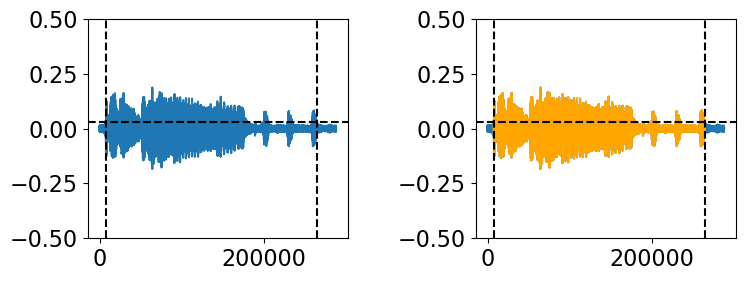

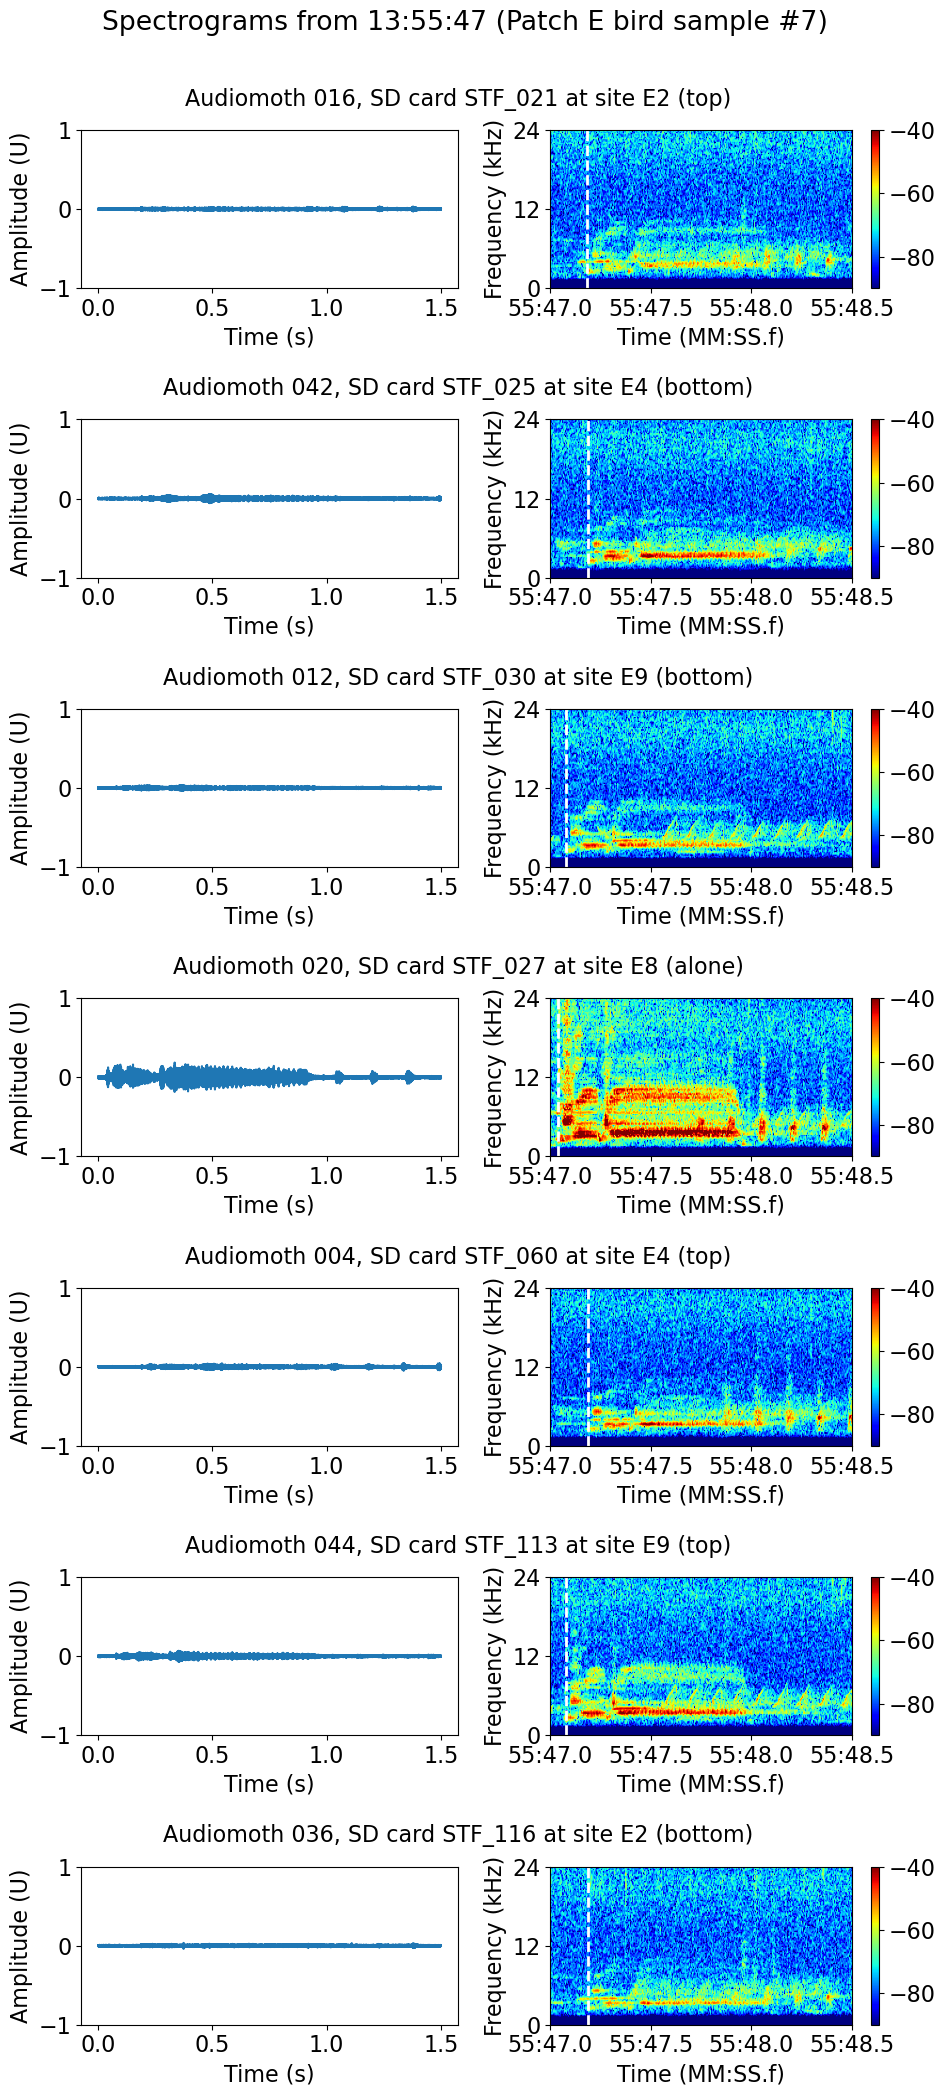

Playback at 13:55:47 localized to [[ 35.82425222 -46.00348037  57.04330898]]


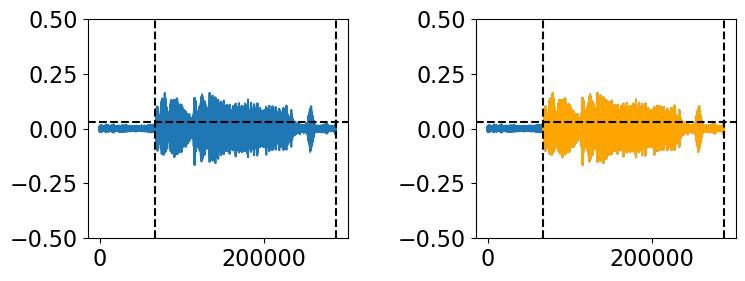

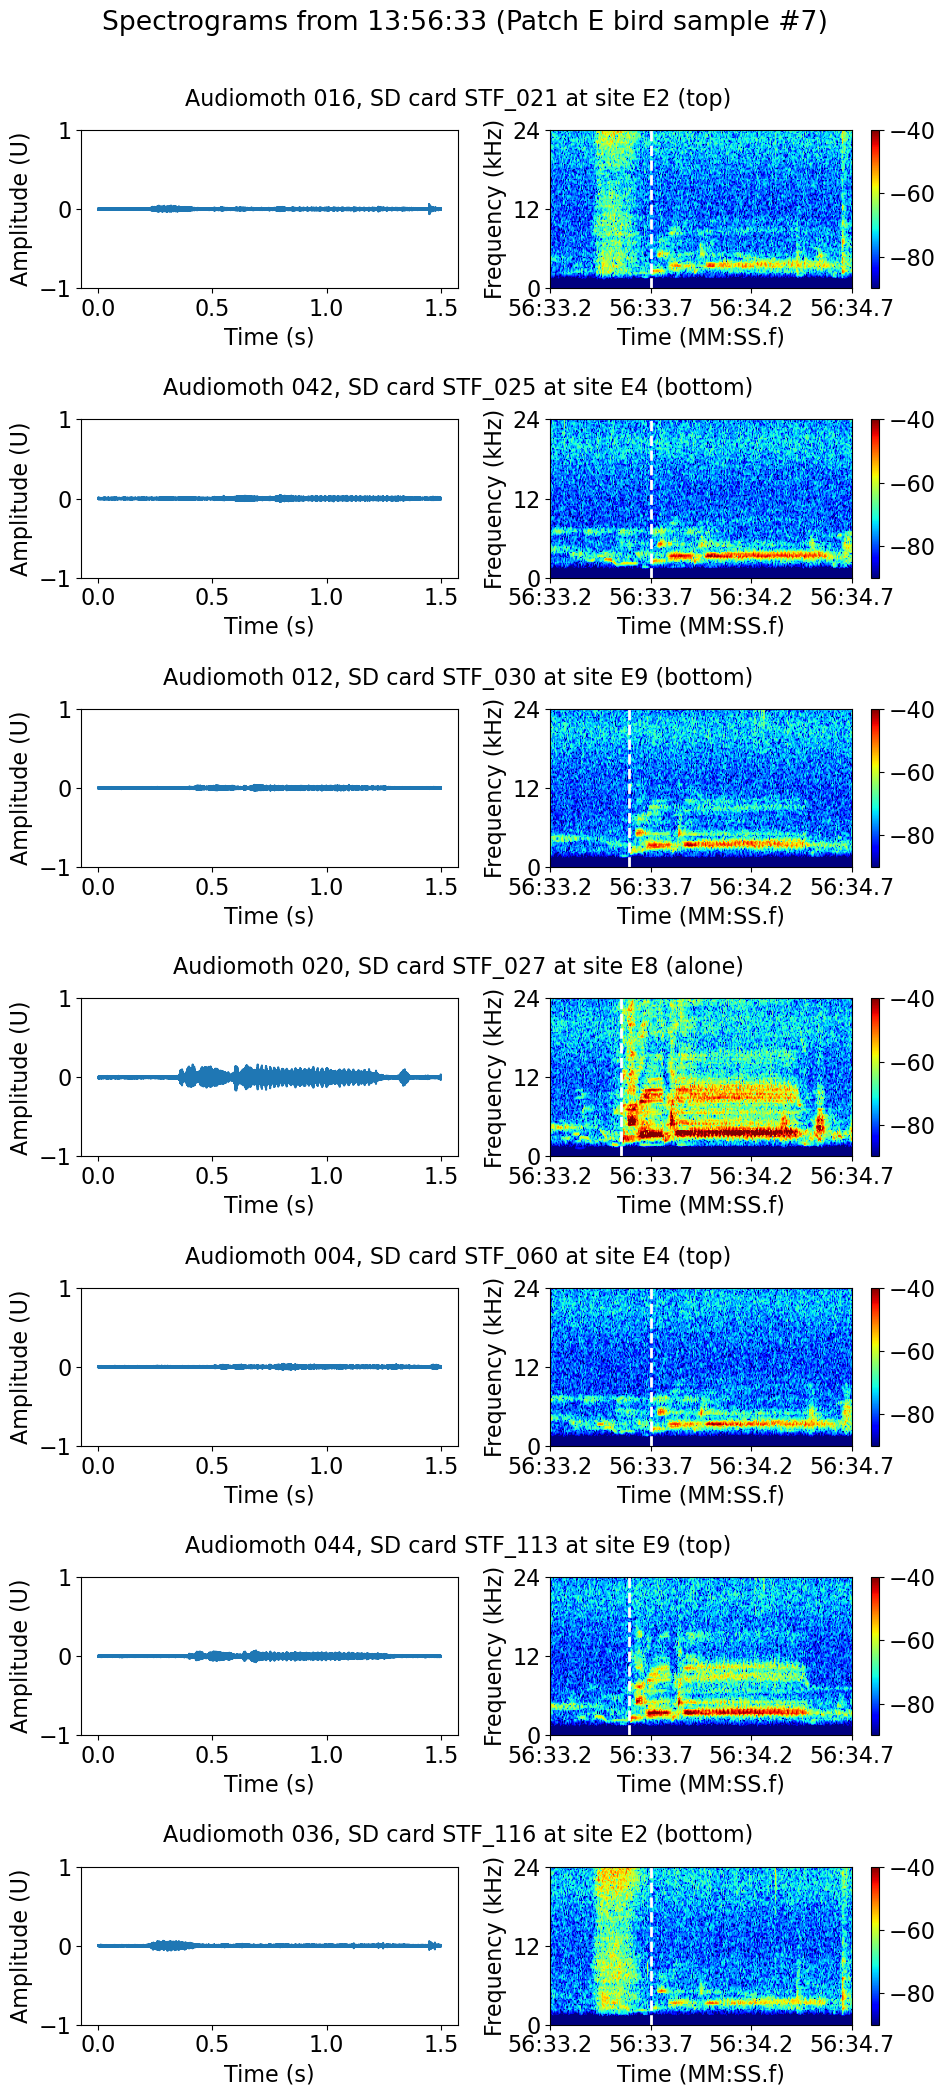

Playback at 13:56:33 localized to [[ 36.05895341 -46.29393675  57.49914538]]


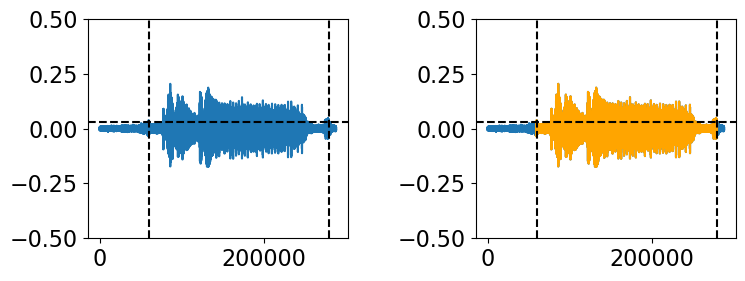

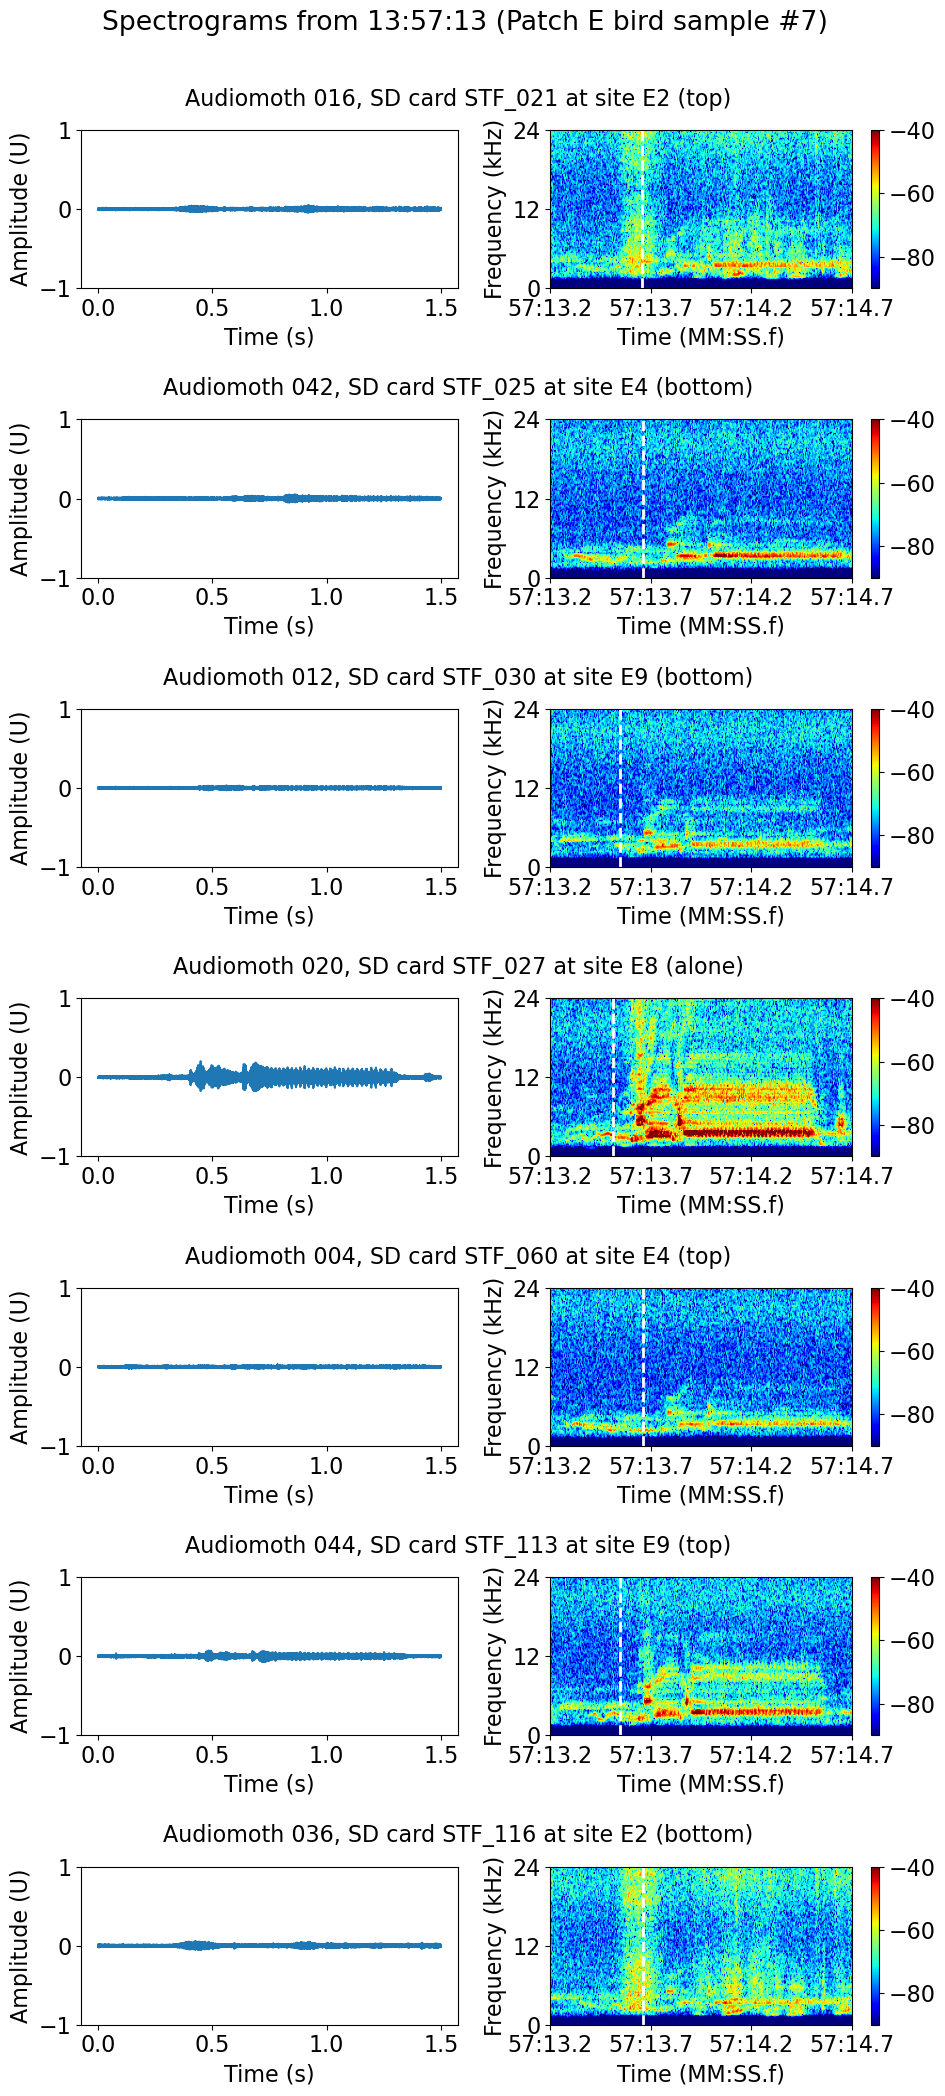

Playback at 13:57:13 localized to [[ 36.50987498 -46.61687214  58.2076794 ]]


In [19]:
%matplotlib inline
recording_start_dt_values = [dt.datetime(2026, 6, 4, 20, 53, 30, 0), dt.datetime(2026, 6, 4, 20, 55, 18, 500000), 
                             dt.datetime(2026, 6, 4, 20, 55, 47, 0), dt.datetime(2026, 6, 4, 20, 56, 33, 200000),
                             dt.datetime(2026, 6, 4, 20, 57, 13, 200000)]

all_playbacks_source_locs = np.zeros((len(recording_start_dt_values[2:]), 3))
all_highpassed_audio_segments = []
for ind, recording_start_dt in enumerate(recording_start_dt_values[2:]):
    recording_start_string = (recording_start_dt - dt.timedelta(hours=7)).strftime('%H:%M:%S')
    SAMPLERATE = 192000

    highpassed_audio_segments = dict()
    audio_segments = dict()
    for example_wav_file in valid_sync_wav_files:
        wav_SD_card = example_wav_file.parts[-2]
        wav_AUDIOMOTH = SD_CARD_TO_AUDIOMOTH_NUM[wav_SD_card]
        if wav_AUDIOMOTH in AUDIOMOTH_AT_PATCHE.keys():
            example_wav_file_dt = dt.datetime.strptime(example_wav_file.name, '%Y%m%d_%H%M%S_PYTHON_SYNC.WAV')
            samples_until_recording_start = (recording_start_dt - example_wav_file_dt).total_seconds()
            recorded_audio = sf.SoundFile(example_wav_file)
            read_offset = samples_until_recording_start
            read_duration_in_secs = 1.5
            recorded_audio.seek(int(SAMPLERATE*read_offset))
            audio_seg = recorded_audio.read(int(SAMPLERATE*read_duration_in_secs))
            audio_segments[wav_AUDIOMOTH] = audio_seg
            highpassed_audio_seg = localize.highpass_audio_signal(audio_seg, SAMPLERATE, 2000)
            highpassed_audio_segments[wav_AUDIOMOTH] = highpassed_audio_seg
    all_highpassed_audio_segments += [highpassed_audio_segments]

    ### PLOT THE TEMPLATE CHANNEL AND THE RELEVANT SEGMENT OF IT
    template_highpassed_signal = highpassed_audio_segments['020']
    fig, ax_all = plt.subplots(1, 2, figsize=(8, 3))

    threshold = 0.03
    first_over_threshold = np.where(template_highpassed_signal>=threshold)[0][0]
    last_over_threshold = np.where(template_highpassed_signal>=threshold)[0][-1]
    relevant_template_highpassed_signal = template_highpassed_signal[first_over_threshold:last_over_threshold]

    ax = ax_all[0]
    ax.plot(template_highpassed_signal)
    ax.axhline(y=threshold, linestyle='dashed', color='k')
    ax.axvline(x=first_over_threshold, linestyle='dashed', color='k')
    ax.axvline(x=last_over_threshold, linestyle='dashed', color='k')
    ax.set_ylim(-0.5, 0.5)

    ax = ax_all[1]
    ax.plot(template_highpassed_signal)
    ax.plot(np.arange(first_over_threshold, last_over_threshold), relevant_template_highpassed_signal, color='orange')
    ax.axhline(y=threshold, linestyle='dashed', color='k')
    ax.axvline(x=first_over_threshold, linestyle='dashed', color='k')
    ax.axvline(x=last_over_threshold, linestyle='dashed', color='k')
    ax.set_ylim(-0.5, 0.5)

    fig.tight_layout()
    plt.show()

    ### PLOT THE SPECTROGRAMS OF ALL CHANNELS AND THE TIME DELAYS BETWEEN THEM USING THE CROSS-CORRELATION OUTPUT
    fig, ax_all = plt.subplots(len(AUDIOMOTH_AT_PATCHE), 2, figsize=(10, 3*len(AUDIOMOTH_AT_PATCHE)))
    plt.rcParams.update({'font.size': 16})
    fig.suptitle(f'Spectrograms from {recording_start_string} (Patch E bird sample #7)', y=1.0)
    i = 0
    time_delay_in_seconds_matrix = np.zeros(len(AUDIOMOTH_AT_PATCHE))
    time_delay_in_seconds_dictionary = dict()
    time_delay_in_seconds_highpassed_matrix = np.zeros(len(AUDIOMOTH_AT_PATCHE))
    time_delay_in_seconds_highpassed_dictionary = dict()
    for example_wav_file in valid_sync_wav_files:
        wav_SD_card = example_wav_file.parts[-2]
        wav_AUDIOMOTH = SD_CARD_TO_AUDIOMOTH_NUM[wav_SD_card]
        if wav_AUDIOMOTH in AUDIOMOTH_AT_PATCHE.keys():

            highpassed_audio_seg = highpassed_audio_segments[wav_AUDIOMOTH]

            signal1 = highpassed_audio_seg
            signal2 = relevant_template_highpassed_signal
            cross_correlation = sp.signal.correlate((signal1), (signal2), mode='full')
            lags = sp.signal.correlation_lags(len(signal1), len(signal2), mode='full')
            max_lag_index = np.argmax(cross_correlation)
            time_delay_in_samples = lags[max_lag_index]
            time_delay_in_seconds_highpassed = time_delay_in_samples / SAMPLERATE
            time_delay_in_seconds_highpassed_dictionary[wav_AUDIOMOTH] = time_delay_in_seconds_highpassed

            vmax = -40
            vmin = -90

            audio_features = dict()
            audio_features['audio_seg'] = highpassed_audio_seg
            audio_features['sample_rate'] = SAMPLERATE
            audio_features['start'] = read_offset
            audio_features['duration'] = read_duration_in_secs

            spec_features = dict()
            spec_features['NFFT'] = 1024 # When segments are short, NFFT should also be small to best see calls (must always be > 128)
            spec_features['cmap'] = 'jet' # This colormap shows best contrast between noise and signals
            spec_features['vmin'] = vmin
            spec_features['vmax'] = vmax

            audio_seg = audio_features['audio_seg']
            fs = audio_features['sample_rate']
            start = audio_features['start']
            duration = audio_features['duration']

            vmax = spec_features['vmax']
            vmin = spec_features['vmin']
            cmap = spec_features['cmap']
            nfft = spec_features['NFFT']


            ax = ax_all[i, 1]
            spec, freqs, t, im = ax.specgram(audio_seg+1e-6, NFFT=nfft, cmap=cmap, vmin=vmin, vmax=vmax, mode='magnitude', scale='dB')
            ax.axvline(x=time_delay_in_seconds_highpassed*(fs/2), color='w', linestyle='dashed', linewidth=2)
            ax.set_yticks(ticks=np.linspace(0, FREQ_UPPER_LIM, 3), labels=np.linspace(0, FREQ_UPPER_LIM * (fs/2000), 3).astype('int'))
            ax.set_ylim(0, FREQ_UPPER_LIM)
            times = []
            for s in np.linspace(0, duration, 4):
                times += [str(dt.datetime.strftime(recording_start_dt + dt.timedelta(seconds=float(s)), "%M:%S.%f"))[:7]]
            ax.set_xticks(ticks=np.linspace(0, duration*(fs/2), 4), labels=times, rotation=0)
            fig.colorbar(im, ax=ax)
            ax.set_ylabel("Frequency (kHz)")
            ax.set_xlabel("Time (MM:SS.f)") 

            ax = ax_all[i, 0]
            ax.set_title(f"Audiomoth {wav_AUDIOMOTH}, SD card {wav_SD_card} at site {AUDIOMOTH_AT_ALLPATCHES[wav_AUDIOMOTH]}", x=1, y=1.1, fontsize=16)
            ax.plot(np.linspace(0, read_duration_in_secs, int(read_duration_in_secs*fs)), audio_seg)
            ax.set_ylim(-1, 1)
            ax.set_ylabel('Amplitude (U)')
            ax.set_xlabel("Time (s)") 

            i += 1


    fig.tight_layout()
    plt.show()
    t_delay_ref_to_selected_channel = time_delay_in_seconds_highpassed_dictionary['016']
    time_delay_mics_to_selected_ref_channel_temp = np.array([time_delay_in_seconds_highpassed_dictionary['004'],
                                                            time_delay_in_seconds_highpassed_dictionary['020'],
                                                            time_delay_in_seconds_highpassed_dictionary['044'],
                                                            time_delay_in_seconds_highpassed_dictionary['016']])
    IND_OF_SELECTED_CHANNEL = 3
    SOUND_SPEED_AIR = 343
    time_delay_mics_to_selected_ref_channel = (time_delay_mics_to_selected_ref_channel_temp) - (t_delay_ref_to_selected_channel)

    time_delay_mics_to_selected_ref_channel_no_ref = np.delete(time_delay_mics_to_selected_ref_channel, IND_OF_SELECTED_CHANNEL, axis=0)
    measured_d_mics_to_ref = (time_delay_mics_to_selected_ref_channel_no_ref * SOUND_SPEED_AIR)

    measured_dm0_column = measured_d_mics_to_ref.reshape((NUM_NONREFCHANNELS, 1))
    num_noise = 1000

    A_mat = np.hstack(((A_locs_mat_tdoa_meters), measured_dm0_column))
    wm0 = ((xm**2 + ym**2) - (x0**2 + y0**2) - (measured_dm0_column**2))/2
    xs, residuals, rank, sing_vals = sp.linalg.lstsq(A_mat, wm0)

    source_locs = xs[:,0].reshape((1,3))
    all_playbacks_source_locs[ind] = source_locs
    print(f"Playback at {recording_start_string} localized to {source_locs}")

### Inspect the first event’s template-channel audio

Display the filtered sample array for AudioMoth `020` from the first processed event, which is the third entry in the original event-time list.


In [20]:
all_highpassed_audio_segments[0]['020']

array([-0.0013458 , -0.00150927, -0.00123761, ...,  0.00101872,
        0.00113095,  0.00182198])

### Export the filtered template-channel segment

Write the first processed event’s AudioMoth `020` segment to `Audiomoth_020_highpassed.wav` in the current working directory, using `SAMPLERATE` and 16-bit PCM encoding. Running this cell again replaces a file with the same name.


In [21]:
output_path = "Audiomoth_020_highpassed.wav"

sf.write(
    output_path,
    all_highpassed_audio_segments[0]['020'],
    SAMPLERATE,
    subtype="PCM_16",
)

print(f"Saved to: {output_path}")

Saved to: Audiomoth_020_highpassed.wav


### Listen to the filtered template-channel segment

Create an inline audio player for the same AudioMoth `020` segment at `SAMPLERATE`. Playback normalization is enabled to make the segment audible; this does not change the stored array or the previously exported WAV.


In [22]:
from IPython.display import Audio

Audio(
    all_highpassed_audio_segments[0]['020'],
    rate=SAMPLERATE,
    normalize=True,
)

### Inspect the last iterated WAV path

Display the value left in `example_wav_file` by the preceding loops. This is the last iterated path and is not necessarily the AudioMoth `020` recording or even a Patch E recording.


In [23]:
example_wav_file

PosixPath('/Volumes/Elements/recover-20260604/STF_116/20260604_203000_PYTHON_SYNC.WAV')

### Inspect the localization results

Display the three solved event rows. Each row contains the estimated east offset, north offset, and auxiliary reference-range term from the least-squares solve, in meters.


In [24]:
all_playbacks_source_locs

array([[ 35.82425222, -46.00348037,  57.04330898],
       [ 36.05895341, -46.29393675,  57.49914538],
       [ 36.50987498, -46.61687214,  58.2076794 ]])

### Assemble all four receiver positions

Stack the three nonreference receiver positions with the reference origin to create `UBNA_ARRAY_MIC_LOCS`. The row order is E4, E8, E9, E2, and each row contains local east/north coordinates in meters.


In [25]:
UBNA_ARRAY_MIC_LOCS = np.vstack([A_locs_mat_tdoa_meters, ref_A_loc_meters])
UBNA_ARRAY_MIC_LOCS

array([[ 49.10130981,  11.73724225],
       [ 49.72571837, -44.16909586],
       [ 18.30907842, -61.46608445],
       [  0.        ,   0.        ]])

### Plot receivers and source estimates in local coordinates

Enable the interactive Matplotlib widget backend and plot receivers in yellow and estimated event locations in red. Although the axes are three-dimensional, all points are placed at `z = 0`; this visualizes the two-dimensional solution and does not estimate altitude. The widget backend requires a compatible Jupyter environment with `ipympl`.


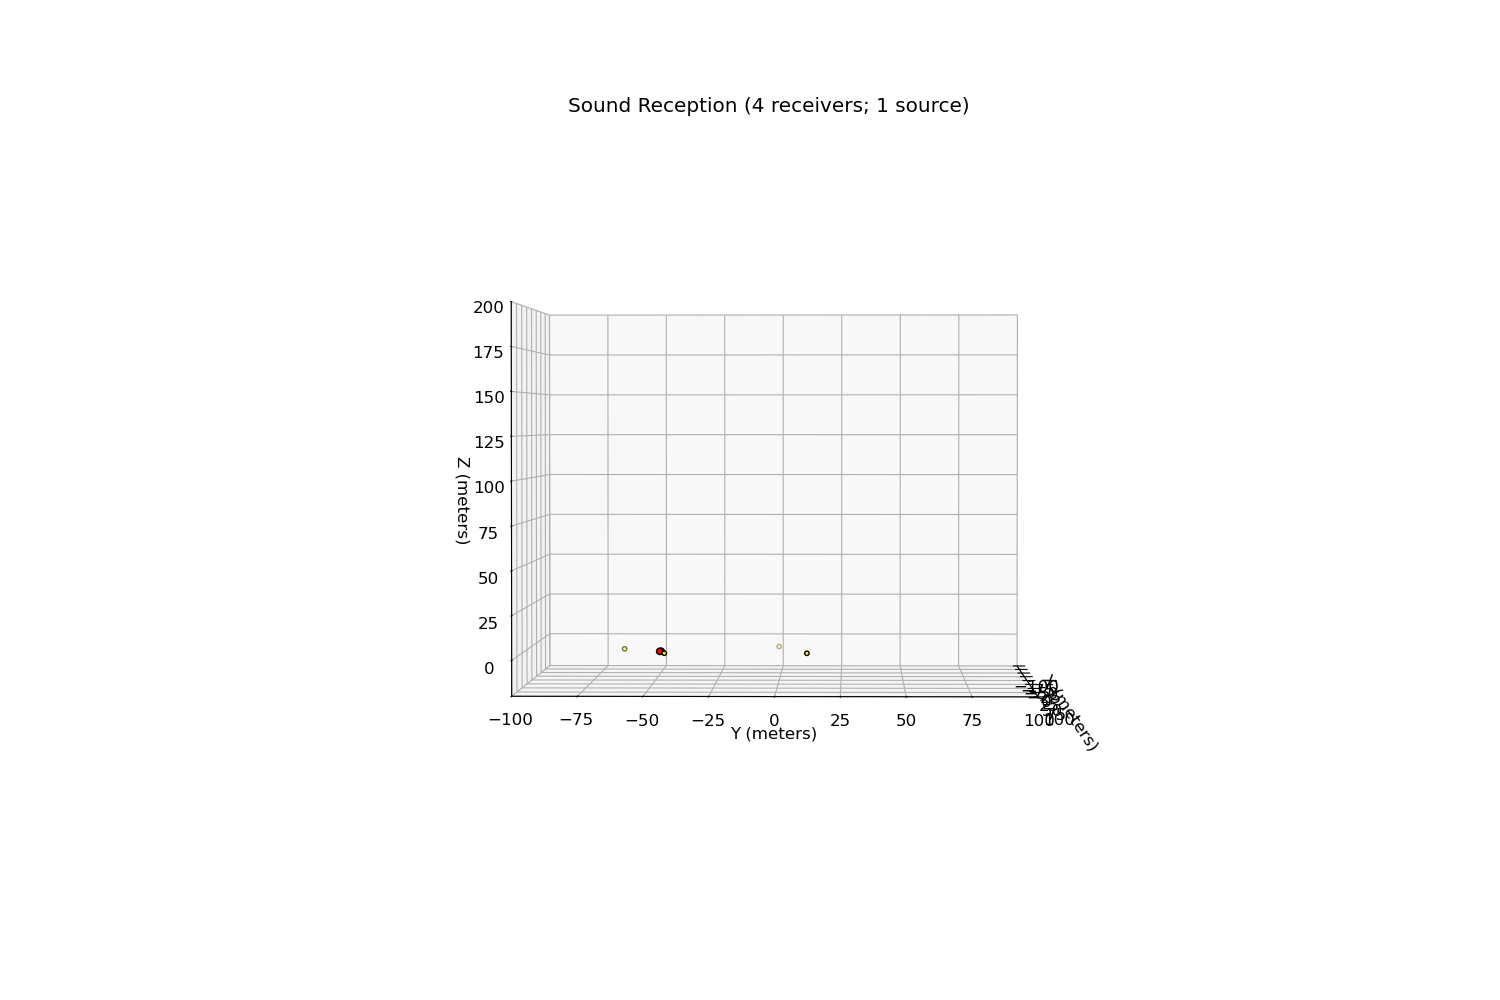

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

%matplotlib widget
fig = plt.figure(figsize=(15, 10))
plt.rcParams.update({'font.size':12})
map_ax_3d = fig.add_subplot(projection='3d')
POINT_SIZE = 40
GRID_SIZE = 200
rN_x = UBNA_ARRAY_MIC_LOCS[:,0]
rN_y = UBNA_ARRAY_MIC_LOCS[:,1]

map_ax_3d.scatter(rN_x, rN_y, 0, s=10, color='yellow', edgecolor='k', zorder=1)
map_ax_3d.scatter(all_playbacks_source_locs[:,0], 
                  all_playbacks_source_locs[:,1], 0, color='r', edgecolor='k', alpha=1, s=POINT_SIZE/2, zorder=2)
    
map_ax_3d.set_xlim(-GRID_SIZE / 2, GRID_SIZE / 2)
map_ax_3d.set_ylim(-GRID_SIZE / 2, GRID_SIZE / 2)
map_ax_3d.set_zlim(-GRID_SIZE / 10, GRID_SIZE)
map_ax_3d.set_xlabel("X (meters)")
map_ax_3d.set_ylabel("Y (meters)")
map_ax_3d.set_zlabel("Z (meters)")
map_ax_3d.set_title(f"Sound Reception ({int(NUM_NONREFCHANNELS+1)} receivers; 1 source)")
map_ax_3d.view_init(elev=1, azim=1)

plt.show()

### Convert source estimates back to latitude and longitude

Define the inverse of the earlier local east/north approximation and apply it to the first two coordinates of every source estimate. Store geographic positions in `playback_latlons` for Folium. The actual reference is E2 through `ref_A_loc`, despite the existing inline comment referring to A7.


In [27]:
def xy_m_to_latlon(ref_lat, ref_lon, x_east_m, y_north_m):
    """Convert local east/north offsets in meters to [latitude, longitude]."""
    R = 6_371_000  # same value used by latlon_delta_xy_m

    lat = ref_lat + np.degrees(y_north_m / R)
    mean_lat = (ref_lat + lat) / 2

    lon = ref_lon + np.degrees(
        x_east_m / (R * np.cos(np.radians(mean_lat)))
    )

    return [lat, lon]


# A7 is the (0, 0) reference microphone.
playback_latlons = [
    xy_m_to_latlon(
        ref_A_loc[0],
        ref_A_loc[1],
        x_east_m=source[0],
        y_north_m=source[1],
    )
    for source in all_playbacks_source_locs
]

### Map the estimates on OpenStreetMap

Build an interactive street map with black X microphone markers, cyan source markers, east/north tooltips, a distance-measurement tool, and a legend. Add JavaScript intended to display the current map center and zoom after map loading and movement. The microphone labels in this cell do not match the geometry defined above: the markers labeled E2, E4, and E8 use E4, E8, and E2 coordinates, respectively. The legend also uses a fixed playback-test label for all plotted events.


In [28]:
from folium.plugins import MeasureControl

map = folium.Map(
    location=[47.65482429333334, -122.29547748000003],
    zoom_start=18,
    control_scale=True,
    max_zoom=24,
    tiles=None,
)

folium.TileLayer(
    tiles="https://tile.openstreetmap.org/{z}/{x}/{y}.png",
    attr="© OpenStreetMap contributors",
    name="OpenStreetMap",
    max_native_zoom=19,
    max_zoom=24,
).add_to(map)

marker_locations = [("Microphone (E2)", A_locs_mat_tdoa[0,:2].tolist()),
                    ("Microphone (E4)", A_locs_mat_tdoa[1,:2].tolist()),
                    ("Microphone (E8)", ref_A_loc[:2].tolist()),
                    ("Microphone (E9)", A_locs_mat_tdoa[2,:2].tolist())]

for name, location in marker_locations:
    coordinate_label = f"{name}"

    x_icon = folium.DivIcon(
        icon_size=(16, 16),
        icon_anchor=(8, 8),
        html='<div style="font-size: 16px; font-weight: bold; color: black; '
             'line-height: 16px; text-align: center;">X</div>',
    )

    folium.Marker(location=location, icon=x_icon, 
                  tooltip=folium.Tooltip(
                            coordinate_label,
                            direction="right",
                            offset=(8, 0))).add_to(map)
    
for i, (location, source) in enumerate(zip(playback_latlons, all_playbacks_source_locs), start=1):
    x_east, y_north = source[:2]

    folium.CircleMarker(
        location=location,
        radius=5,
        color="black",
        weight=1,
        fill=True,
        fill_color="cyan",
        fill_opacity=1,
        tooltip=folium.Tooltip(
            (
                f"Playback {i}<br>"
                f"East: {x_east:.2f} m<br>"
                f"North: {y_north:.2f} m"
            ),
            sticky=True,
        )).add_to(map)

# The ruler button measures a line drawn between any points on the map.
MeasureControl(position="topleft", primary_length_unit="meters", secondary_length_unit="feet").add_to(map)
legend_html = """
<div style="
    position: fixed;
    bottom: 40px;
    left: 40px;
    z-index: 9999;
    background-color: white;
    border: 2px solid #777;
    border-radius: 5px;
    padding: 10px 14px;
    font-size: 14px;
    box-shadow: 0 1px 5px rgba(0, 0, 0, 0.35);
">
    <div style="font-weight: bold; margin-bottom: 8px;">Legend</div>

    <div style="display: flex; align-items: center; margin-bottom: 6px;">
        <span style="
            display: inline-block;
            width: 18px;
            margin-right: 8px;
            color: black;
            font-size: 18px;
            font-weight: bold;
            text-align: center;
        ">X</span>
        <span>Microphone</span>
    </div>

    <div style="display: flex; align-items: center;">
        <span style="
            display: inline-block;
            width: 10px;
            height: 10px;
            margin-left: 4px;
            margin-right: 12px;
            background-color: cyan;
            border: 1px solid black;
            border-radius: 50%;
        "></span>
        <span>Playback test #4 localization</span>
    </div>
</div>
"""

map.get_root().html.add_child(folium.Element(legend_html))

map_name = map.get_name()

view_display = folium.Element(f"""
<script>
document.addEventListener("DOMContentLoaded", function () {{
    const leafletMap = {map_name};

    const viewBox = L.control({{position: "topright"}});

    viewBox.onAdd = function () {{
        this._div = L.DomUtil.create("div", "current-view-box");
        this._div.style.backgroundColor = "white";
        this._div.style.padding = "8px";
        this._div.style.border = "1px solid #777";
        this._div.style.borderRadius = "4px";
        this._div.style.fontSize = "12px";
        this.update();
        return this._div;
    }};

    viewBox.update = function () {{
        const center = leafletMap.getCenter();
        const zoom = leafletMap.getZoom();

        this._div.innerHTML =
            "<b>Current view</b><br>" +
            "Latitude: " + center.lat.toFixed(8) + "<br>" +
            "Longitude: " + center.lng.toFixed(8) + "<br>" +
            "Zoom: " + zoom;
    }};

    viewBox.addTo(leafletMap);

    leafletMap.on("moveend zoomend", function () {{
        viewBox.update();
    }});
}});
</script>
""")

map.get_root().html.add_child(view_display)

map

### Inspect the Patch E device mapping

Display the AudioMoth-to-position dictionary for Patch E to check device identities against the channels used for localization.


In [ ]:
AUDIOMOTH_AT_PATCHE

{'016': 'E2 (top)',
 '036': 'E2 (bottom)',
 '004': 'E4 (top)',
 '042': 'E4 (bottom)',
 '020': 'E8 (alone)',
 '044': 'E9 (top)',
 '012': 'E9 (bottom)'}

### Map the estimates with an aerial imagery option

Create a new map with selectable OpenStreetMap and King County 2025 aerial layers. Show microphones as large yellow X markers and event estimates as orange circles with local-coordinate tooltips. Add a ruler, an RWB localization legend, and larger scale-bar text. This cell repeats the same E2/E4/E8 marker-label mismatch described above and replaces the `map` variable with this new view.


In [ ]:
from folium.plugins import MeasureControl

map = folium.Map(
    location=[47.65482429333334, -122.29547748000003],
    zoom_start=18,
    control_scale=True,
    max_zoom=24,
    tiles=None,
)

folium.TileLayer(
    tiles="https://tile.openstreetmap.org/{z}/{x}/{y}.png",
    attr="© OpenStreetMap contributors",
    name="OpenStreetMap",
    max_native_zoom=19,
    max_zoom=24,
).add_to(map)

folium.TileLayer(
    tiles=(
        "https://gismaps.kingcounty.gov/arcgis/rest/services/"
        "BaseMaps/KingCo_Aerial_2025/MapServer/tile/{z}/{y}/{x}"
    ),
    attr="EagleView Technologies, Inc., King County",
    name="King County Aerial 2025",
    max_native_zoom=20,
    max_zoom=21,
).add_to(map)

folium.LayerControl(position="topright").add_to(map)

marker_locations = [("Microphone (E2)", A_locs_mat_tdoa[0,:2].tolist()),
                    ("Microphone (E4)", A_locs_mat_tdoa[1,:2].tolist()),
                    ("Microphone (E8)", ref_A_loc[:2].tolist()),
                    ("Microphone (E9)", A_locs_mat_tdoa[2,:2].tolist())]

for name, location in marker_locations:
    coordinate_label = f"{name}"

    x_icon = folium.DivIcon(
        icon_size=(40, 40),
        icon_anchor=(20, 20),
        html='<div style="font-size: 32px; font-weight: bold; color: yellow; '
            'line-height: 40px; text-align: center;">X</div>',
    )

    folium.Marker(location=location, icon=x_icon, 
                  tooltip=folium.Tooltip(
                            coordinate_label,
                            direction="right",
                            offset=(8, 0))).add_to(map)
    
for i, (location, source) in enumerate(zip(playback_latlons, all_playbacks_source_locs), start=1):
    x_east, y_north = source[:2]

    folium.CircleMarker(
        location=location,
        radius=6,
        color="black",
        weight=1,
        fill=True,
        fill_color="orange",
        fill_opacity=1,
        tooltip=folium.Tooltip(
            (
                f"Playback {i}<br>"
                f"East: {x_east:.2f} m<br>"
                f"North: {y_north:.2f} m"
            ),
            sticky=True,
        )).add_to(map)

# The ruler button measures a line drawn between any points on the map.
MeasureControl(position="topleft", primary_length_unit="meters", secondary_length_unit="feet").add_to(map)
legend_html = """
<div style="
    position: fixed;
    bottom: 60px;
    left: 40px;
    z-index: 9999;
    background-color: gray;
    color: white;
    border: 2px solid #777;
    border-radius: 5px;
    padding: 10px 14px;
    font-size: 18px;
    box-shadow: 0 1px 5px rgba(0, 0, 0, 0.35);
">
    <div style="font-weight: bold; margin-bottom: 8px;">Legend</div>

    <div style="display: flex; align-items: center;">
        <span style="
            display: inline-block;
            width: 10px;
            height: 10px;
            margin-left: 4px;
            margin-right: 12px;
            background-color: orange;
            border: 1px solid black;
            border-radius: 50%;
        "></span>
        <span>RWB localization from synced files</span>
    </div>
</div>
"""

map.get_root().html.add_child(folium.Element(legend_html))

scale_css = """<style>
.leaflet-control-scale-line {
    font-size: 16px !important;
}
</style>"""

map.get_root().header.add_child(folium.Element(scale_css))
map

map

### Create a closer aerial-map view

Create another street/aerial map, starting at zoom 21, with yellow microphone markers and cyan event markers. Include the layer selector, measurement tool, enlarged scale text, and microphone/playback legend; source circles omit the coordinate tooltips used in the previous view. The same E2/E4/E8 marker-label mismatch and fixed playback-test legend remain in this version.


In [ ]:
from folium.plugins import MeasureControl

map = folium.Map(
    location=[47.65482429333334, -122.29547748000003],
    zoom_start=21,
    control_scale=True,
    max_zoom=24,
    tiles=None,
)

folium.TileLayer(
    tiles="https://tile.openstreetmap.org/{z}/{x}/{y}.png",
    attr="© OpenStreetMap contributors",
    name="OpenStreetMap",
    max_native_zoom=19,
    max_zoom=24,
).add_to(map)

folium.TileLayer(
    tiles=(
        "https://gismaps.kingcounty.gov/arcgis/rest/services/"
        "BaseMaps/KingCo_Aerial_2025/MapServer/tile/{z}/{y}/{x}"
    ),
    attr="EagleView Technologies, Inc., King County",
    name="King County Aerial 2025",
    max_native_zoom=20,
    max_zoom=21,
).add_to(map)

folium.LayerControl(position="topright").add_to(map)

marker_locations = [("Microphone (E2)", A_locs_mat_tdoa[0,:2].tolist()),
                    ("Microphone (E4)", A_locs_mat_tdoa[1,:2].tolist()),
                    ("Microphone (E8)", ref_A_loc[:2].tolist()),
                    ("Microphone (E9)", A_locs_mat_tdoa[2,:2].tolist())]

for name, location in marker_locations:
    coordinate_label = f"{name}"

    x_icon = folium.DivIcon(
        icon_size=(40, 40),
        icon_anchor=(20, 20),
        html='<div style="font-size: 32px; font-weight: bold; color: yellow; '
            'line-height: 40px; text-align: center;">X</div>',
    )

    folium.Marker(location=location, icon=x_icon, 
                  tooltip=folium.Tooltip(
                            coordinate_label,
                            direction="right",
                            offset=(8, 0))).add_to(map)
    
for i, (location, source) in enumerate(zip(playback_latlons, all_playbacks_source_locs), start=1):
    x_east, y_north = source[:2]

    folium.CircleMarker(
        location=location,
        radius=6,
        color="black",
        weight=1,
        fill=True,
        fill_color="cyan",
        fill_opacity=1).add_to(map)

# The ruler button measures a line drawn between any points on the map.
MeasureControl(position="topleft", primary_length_unit="meters", secondary_length_unit="feet").add_to(map)
legend_html = """
<div style="
    position: fixed;
    bottom: 60px;
    left: 40px;
    z-index: 9999;
    background-color: gray;
    color: white;
    border: 2px solid #777;
    border-radius: 5px;
    padding: 10px 14px;
    font-size: 18px;
    box-shadow: 0 1px 5px rgba(0, 0, 0, 0.35);
">
    <div style="font-weight: bold; margin-bottom: 8px;">Legend</div>

    <div style="display: flex; align-items: center; margin-bottom: 6px;">
        <span style="
            display: inline-block;
            width: 18px;
            margin-right: 8px;
            color: yellow;
            font-size: 18px;
            font-weight: bold;
            text-align: center;
        ">X</span>
        <span>Microphone</span>
    </div>

    <div style="display: flex; align-items: center;">
        <span style="
            display: inline-block;
            width: 10px;
            height: 10px;
            margin-left: 4px;
            margin-right: 12px;
            background-color: cyan;
            border: 1px solid black;
            border-radius: 50%;
        "></span>
        <span>Playback test #4 localization</span>
    </div>
</div>
"""

map.get_root().html.add_child(folium.Element(legend_html))

scale_css = """<style>
.leaflet-control-scale-line {
    font-size: 16px !important;
}
</style>"""

map.get_root().header.add_child(folium.Element(scale_css))
map

map

### Empty scratch cell

The following cell is empty and performs no operation. It is available for additional inspection or analysis.
